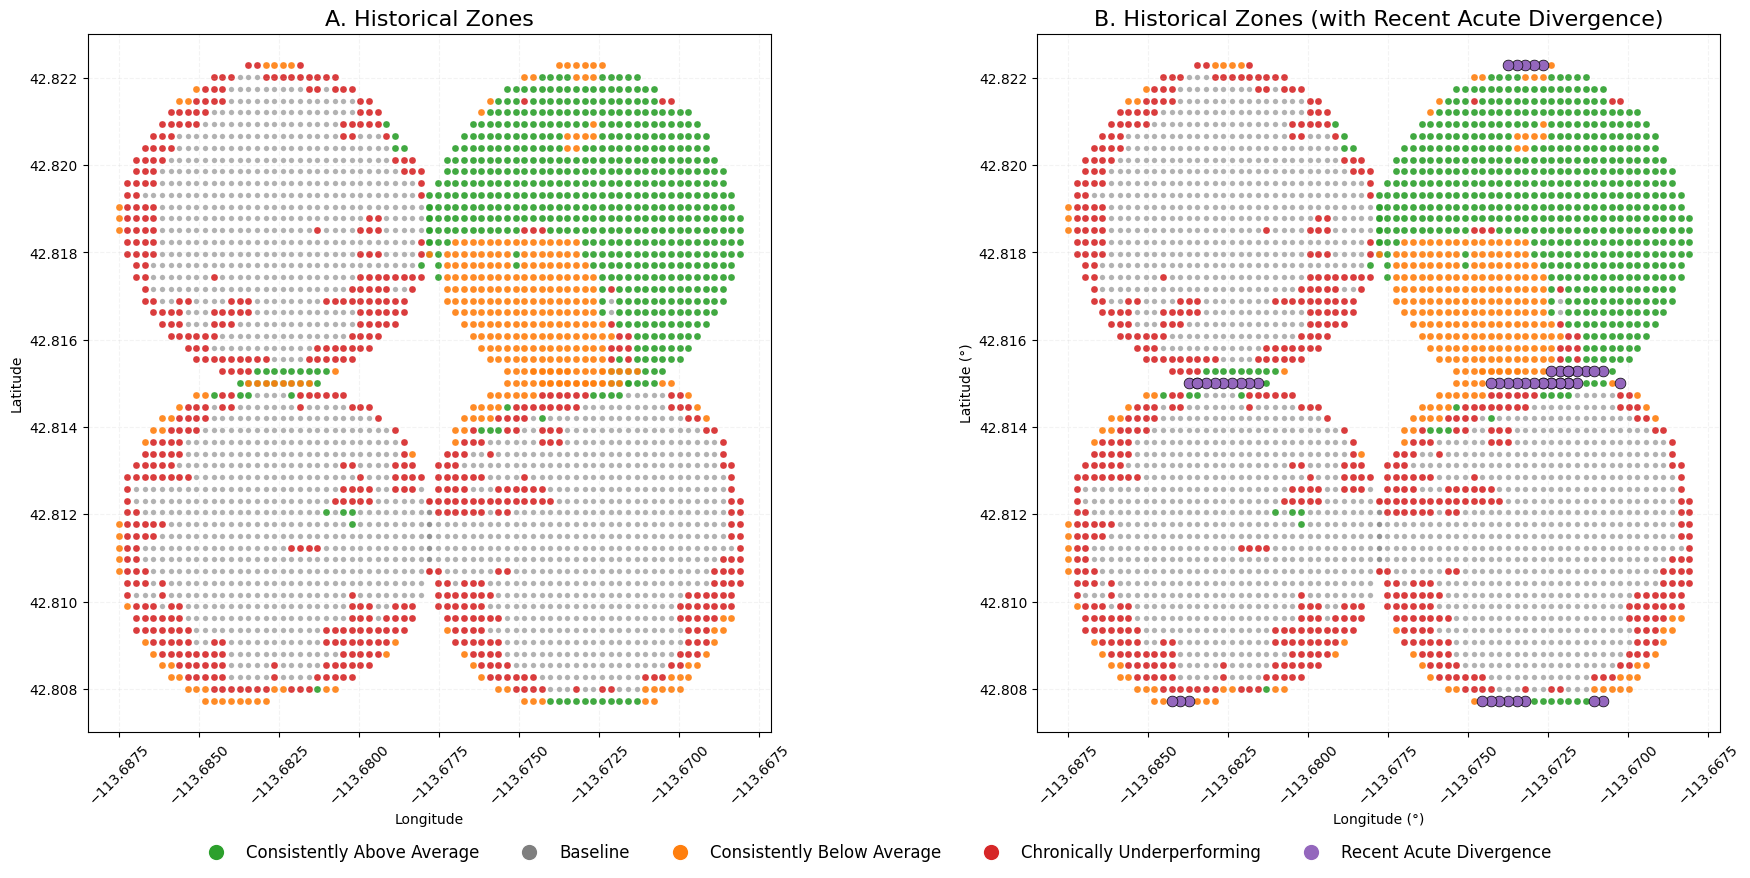

In [31]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances_argmin_min

# ==========================================
# 1. LOAD DATA
# ==========================================
input_csv = "../data/pixel_level_ET_timeseries.csv"
results_csv = "../data/subfield_anomaly_results_8mo.csv"

df = pd.read_csv(input_csv)
results_df = pd.read_csv(results_csv)

df = df[df['field_id'].isin([26,27,39,42])]
results_df = results_df[results_df['field_id'].isin([26,27,39,42])]

# Create pixel ID
df['pixel_id'] = df['field_id'].astype(str) + "_" + df['x'].astype(str) + "_" + df['y'].astype(str)

# Compute historical stats
pixel_stats = df.groupby('pixel_id')['relative_ET'].agg(
    lt_mean='mean',
    lt_std='std'
).reset_index()

# Merge
master_df = results_df.merge(pixel_stats, on='pixel_id')

# ==========================================
# 2. K-MEANS (WITH ANOMALY FEATURE)
# ==========================================
features = ['lt_mean', 'lt_std', 'temporal_persistence', 'chronos_anomaly_score']
X = master_df[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
master_df['ml_cluster'] = kmeans.fit_predict(X_scaled)

# ==========================================
# 3. IDENTIFY CLUSTERS
# ==========================================
cluster_summary = master_df.groupby('ml_cluster')[features].mean()

# --- Step 1: Identify anomaly cluster ---
anomaly_cluster = cluster_summary['chronos_anomaly_score'].idxmax()

# --- Step 2: Stable clusters ---
stable_clusters = cluster_summary.drop(index=anomaly_cluster)

# --- Step 3: Label stable clusters ---
above_avg_cluster = stable_clusters['lt_mean'].idxmax()
below_avg_cluster = stable_clusters['lt_mean'].idxmin()

remaining = stable_clusters.drop(index=[above_avg_cluster, below_avg_cluster])
variable_cluster = remaining['lt_std'].idxmax()
baseline_cluster = remaining.drop(index=variable_cluster).index[0]

# --- Step 4: Assign names ---
cluster_names = {
    anomaly_cluster: "Recent Acute Divergence",
    above_avg_cluster: "Consistently Above Average",
    below_avg_cluster: "Consistently Below Average",
    variable_cluster: "Chronically Underperforming",
    baseline_cluster: "Baseline"
}

master_df['current_zone_name'] = master_df['ml_cluster'].map(cluster_names)

# ==========================================
# 4. REMOVE ANOMALY INFLUENCE (REASSIGNMENT)
# ==========================================
hist_features = ['lt_mean', 'lt_std']
hist_scaler = StandardScaler()
X_hist_scaled = hist_scaler.fit_transform(master_df[hist_features])

stable_cluster_ids = stable_clusters.index.tolist()
stable_centroids = []

for cid in stable_cluster_ids:
    centroid = X_hist_scaled[master_df['ml_cluster'] == cid].mean(axis=0)
    stable_centroids.append(centroid)

anomaly_mask = master_df['ml_cluster'] == anomaly_cluster

# Reassign anomaly pixels to nearest stable cluster
master_df['historical_zone_name'] = master_df['current_zone_name']

if anomaly_mask.sum() > 0:
    anomaly_points = X_hist_scaled[anomaly_mask]
    closest_idx, _ = pairwise_distances_argmin_min(anomaly_points, stable_centroids)

    fallback_cluster_ids = [stable_cluster_ids[i] for i in closest_idx]
    fallback_names = [cluster_names[cid] for cid in fallback_cluster_ids]

    master_df.loc[anomaly_mask, 'historical_zone_name'] = fallback_names

# ==========================================
# 5. SAVE OUTPUT
# ==========================================
# master_df.to_csv("../data/kmeans_hybrid_results.csv", index=False)

# ==========================================
# 6. COLORS
# ==========================================
scientific_colors = {
    "Consistently Above Average": "#2ca02c",
    "Baseline": "#7f7f7f",
    "Consistently Below Average": "#ff7f0e",
    "Chronically Underperforming": "#d62728",
    "Recent Acute Divergence": "#9467bd"
}

# ==========================================
# 7. BUILD GEO DATAFRAME
# ==========================================
gdf_ml = gpd.GeoDataFrame(
    master_df,
    geometry=gpd.points_from_xy(master_df.x.astype(float), master_df.y.astype(float)),
    crs="EPSG:4326"
)

# ==========================================
# 8. TWO-PANEL FIGURE
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# ---------------------------
# PANEL A: HISTORICAL (CLEAN)
# ---------------------------
for zone in ["Consistently Above Average", "Baseline",
             "Consistently Below Average", "Chronically Underperforming"]:

    subset = gdf_ml[gdf_ml['historical_zone_name'] == zone]

    if not subset.empty:
        subset.plot(
            ax=ax1,
            color=scientific_colors[zone],
            markersize=25 if zone != "Baseline" else 15,
            alpha=0.9 if zone != "Baseline" else 0.6,
            edgecolor='white',
            linewidth=0.1
        )

ax1.set_title("A. Historical Zones", fontsize=16)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.grid(alpha=0.15, linestyle='--')
ax1.ticklabel_format(style='plain', useOffset=False)
ax1.tick_params(axis='x', rotation=45)
# ---------------------------
# PANEL B: CURRENT + ANOMALY
# ---------------------------
for zone, color in scientific_colors.items():

    subset = gdf_ml[gdf_ml['current_zone_name'] == zone]

    if not subset.empty:
        if zone == "Recent Acute Divergence":
            subset.plot(
                ax=ax2,
                color=color,
                markersize=60,
                alpha=1.0,
                edgecolor='black',
                linewidth=0.5,
                zorder=5
            )
        else:
            subset.plot(
                ax=ax2,
                color=color,
                markersize=25 if zone != "Baseline" else 15,
                alpha=0.9 if zone != "Baseline" else 0.6,
                edgecolor='white',
                linewidth=0.1,
                zorder=1
            )

ax2.set_title("B. Historical Zones (with Recent Acute Divergence)", fontsize=16)
ax2.set_xlabel("Longitude (°)")
ax2.set_ylabel("Latitude (°)")
ax2.grid(alpha=0.15, linestyle='--')
ax2.ticklabel_format(style='plain', useOffset=False)
ax2.tick_params(axis='x', rotation=45)
# ==========================================
# 9. LEGEND
# ==========================================
legend_elements = [
    mlines.Line2D([0], [0], marker='o', color='w', label=zone,
                  markerfacecolor=color, markersize=12)
    for zone, color in scientific_colors.items()
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.02),
    ncol=5,
    fontsize=12,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18, wspace=0)
plt.savefig("./Figure1.png", dpi = 300)
plt.show()

In [29]:
master_df.head()

,pixel_id,chronos_anomaly_score,forecast_uncertainty,temporal_persistence,is_outlier,field_id,x,y,lt_mean,lt_std,ml_cluster,current_zone_name,historical_zone_name
0,26_-113.67780170231111_42.81069708493459,0.070846,0.083357,0.310890,False,26,-113.677802,42.810697,1.019807,0.136003,4,Baseline,Baseline
1,26_-113.67780170231111_42.810966579519835,0.093287,0.085049,0.221578,False,26,-113.677802,42.810967,1.016329,0.140323,4,Baseline,Baseline
2,26_-113.67780170231111_42.81123607410507,0.097824,0.100790,0.268950,False,26,-113.677802,42.811236,1.074429,0.164615,4,Baseline,Baseline
3,26_-113.67780170231111_42.81150556869031,0.080486,0.097389,0.221879,False,26,-113.677802,42.811506,1.100178,0.177259,4,Baseline,Baseline
4,26_-113.67780170231111_42.81177506327554,0.091594,0.091625,0.122850,False,26,-113.677802,42.811775,1.056752,0.139380,4,Baseline,Baseline


In [33]:
import rasterio
import seaborn as sns
from sklearn.metrics import cohen_kappa_score

legacy_raster_path = "../data/difference_new_RAT_lyr_magicValley_1986_2020_cog.tif"

# ==========================================
# 1. SAMPLE LEGACY RASTER AT K-MEANS PIXELS
# ==========================================
print("Sampling legacy raster...")
# Extract coordinate pairs from your master_df
coords = list(zip(master_df['x'].astype(float), master_df['y'].astype(float)))

# Sample the raster at these exact coordinates
with rasterio.open(legacy_raster_path) as src:
    # src.sample returns a generator of arrays; we grab the first band's value [0]
    master_df['legacy_value'] = [val[0] for val in src.sample(coords)]

# Handle any NoData values from the raster (e.g., if raster has -9999 for out of bounds)
# Assuming 0 is neutral/no persistence in the legacy map
master_df['legacy_value'] = master_df['legacy_value'].apply(lambda x: x if x in [1, -1] else 0)


# ==========================================
# 2. CROSSWALK K-MEANS ZONES TO LEGACY SCALE
# ==========================================
def map_to_legacy_scale(zone):
    if zone == "Consistently Above Average":
        return 1
    elif zone in ["Consistently Below Average", "Chronically Underperforming"]:
        return -1
    else:
        return 0  # Baseline 

master_df['kmeans_mapped'] = master_df['historical_zone_name'].apply(map_to_legacy_scale)


# ==========================================
# 3. STATISTICAL COMPARISON (CONFUSION MATRIX)
# ==========================================
# Filter to only look at pixels where AT LEAST ONE method detected a pattern 
signal_mask = (master_df['legacy_value'] != 0) | (master_df['kmeans_mapped'] != 0)
comparison_df = master_df[signal_mask].copy()

# Generate Crosstab (Confusion Matrix)
crosstab = pd.crosstab(
    comparison_df['legacy_value'], 
    comparison_df['kmeans_mapped'], 
    rownames=['Legacy t-test (Fig 7b)'], 
    colnames=['K-Means (Historical)']
)
print("\n--- Confusion Matrix ---")
print(crosstab)

# ==========================================
# 4. SPATIAL AGREEMENT CLASSIFICATION
# ==========================================
def categorize_agreement(row):
    leg = row['legacy_value']
    km = row['kmeans_mapped']
    
    if leg == km and leg != 0:
        return "Strong Agreement (Both Detected)"
    elif leg == km and leg == 0:
        return "Agreement (Both Neutral)"
    elif leg == 0 and km != 0:
        return "K-Means Discovered (New Pattern)"
    elif leg != 0 and km == 0:
        return "Legacy Only (Missed by K-Means)"
    else:
        return "Direct Contradiction (Opposite Signs)"

master_df['agreement_class'] = master_df.apply(categorize_agreement, axis=1)

# ==========================================
# 5. VISUALIZE AGREEMENT MAP
# ==========================================
agreement_colors = {
    "Strong Agreement (Both Detected)": "#2ca02c",  # Green
    "Agreement (Both Neutral)": "#e0e0e0",          # Light Grey
    "K-Means Discovered (New Pattern)": "#1f77b4",  # Blue
    "Legacy Only (Missed by K-Means)": "#ff7f0e",   # Orange
    "Direct Contradiction (Opposite Signs)": "#d62728" # Red
}

# Update GeoDataFrame with new columns
gdf_compare = gpd.GeoDataFrame(
    master_df,
    geometry=gpd.points_from_xy(master_df.x.astype(float), master_df.y.astype(float)),
    crs="EPSG:4326"
)

Sampling legacy raster...

--- Confusion Matrix ---
K-Means (Historical)     -1    0    1
Legacy t-test (Fig 7b)               
-1.0                    444  111   26
 0.0                    449    0  285
 1.0                     95  855  304


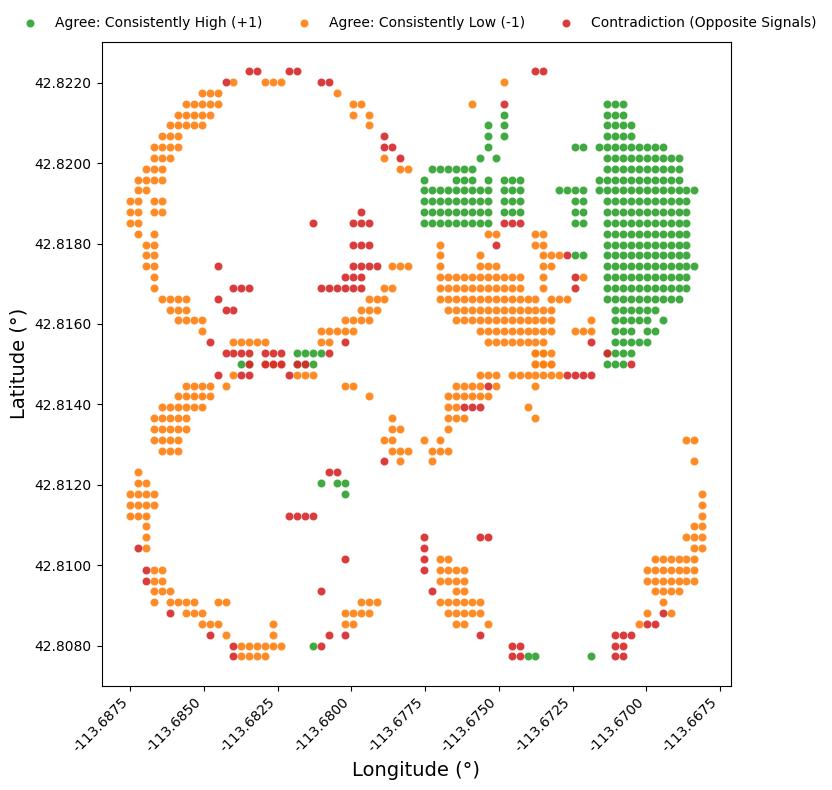

In [34]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 1. Filter for pixels where BOTH methods detected a signal (+1 or -1)
both_signal_mask = (master_df['legacy_value'] != 0) & (master_df['kmeans_mapped'] != 0)
direction_df = master_df[both_signal_mask].copy()

# 2. Classify agreement direction
def get_direction_agreement(row):
    if row['legacy_value'] == 1 and row['kmeans_mapped'] == 1:
        return "Agree: Consistently High (+1)"
    elif row['legacy_value'] == -1 and row['kmeans_mapped'] == -1:
        return "Agree: Consistently Low (-1)"
    else:
        return "Contradiction (Opposite Signals)"

direction_df['direction_class'] = direction_df.apply(get_direction_agreement, axis=1)

# 3. Convert to GeoDataFrame (KEEP geographic CRS)
gdf_direction = gpd.GeoDataFrame(
    direction_df,
    geometry=gpd.points_from_xy(direction_df.x, direction_df.y),
    crs="EPSG:4326"
)

# 4. Color mapping
dir_colors = {
    "Agree: Consistently High (+1)": "#2ca02c",   # green
    "Agree: Consistently Low (-1)": "#ff7f0e",    # orange
    "Contradiction (Opposite Signals)": "#d62728" # red
}

# 5. Plot
fig, ax = plt.subplots(figsize=(10, 8))

for dir_type, color in dir_colors.items():
    subset = gdf_direction[gdf_direction['direction_class'] == dir_type]
    if not subset.empty:
        subset.plot(
            ax=ax,
            color=color,
            markersize=35,
            alpha=0.9,
            label=dir_type,
            edgecolor='white',
            linewidth=0.2
        )

# 6. Titles and labels
# ax.set_title("Signal Directionality: Where Both Methods Detect a Pattern", fontsize=14)
ax.set_xlabel("Longitude (°)", fontsize=14)
ax.set_ylabel("Latitude (°)", fontsize=14)

# 7. Remove scientific notation / offset
ax.ticklabel_format(style='plain', useOffset=False)

# 8. Clean numeric formatting
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

# 9. Rotate x-axis labels
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# 10. Legend formatting
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.savefig("./Figure2.png", dpi =300)
plt.show()

In [35]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score, accuracy_score

# 1. Isolate pixels where BOTH methods detected an active signal (+1 or -1)
both_signal_mask = (master_df['legacy_value'] != 0) & (master_df['kmeans_mapped'] != 0)
signal_df = master_df[both_signal_mask].copy()

total_shared_signals = len(signal_df)

# 2. Confusion Matrix for Shared Signals
print("--- Confusion Matrix (Shared Signals Only) ---")
crosstab_signal = pd.crosstab(
    signal_df['legacy_value'], 
    signal_df['kmeans_mapped'], 
    rownames=['Legacy t-test'], 
    colnames=['ML Pipeline']
)
print(crosstab_signal)
print("\n")

# 3. Core Agreement Statistics
agree_low = len(signal_df[(signal_df['legacy_value'] == -1) & (signal_df['kmeans_mapped'] == -1)])
agree_high = len(signal_df[(signal_df['legacy_value'] == 1) & (signal_df['kmeans_mapped'] == 1)])
contradictions = len(signal_df[signal_df['legacy_value'] != signal_df['kmeans_mapped']])

total_agreements = agree_low + agree_high

print("--- Directional Agreement Statistics ---")
print(f"Total Pixels with Shared Signals: {total_shared_signals}")
print(f"Total Exact Directional Agreement: {total_agreements} pixels ({total_agreements/total_shared_signals*100:.1f}%)")
print(f"  - Both detected Consistently Low (-1): {agree_low} pixels ({agree_low/total_shared_signals*100:.1f}%)")
print(f"  - Both detected Consistently High (+1): {agree_high} pixels ({agree_high/total_shared_signals*100:.1f}%)")
print(f"Total Contradictions (Opposite directions): {contradictions} pixels ({contradictions/total_shared_signals*100:.1f}%)")

# 4. Advanced Metrics for Shared Signals
kappa_signal = cohen_kappa_score(signal_df['legacy_value'], signal_df['kmeans_mapped'])
accuracy_signal = accuracy_score(signal_df['legacy_value'], signal_df['kmeans_mapped'])

print("\n--- Advanced Metrics ---")
print(f"Directional Accuracy: {accuracy_signal:.3f}")
print(f"Cohen's Kappa (Shared Signals): {kappa_signal:.3f}")

--- Confusion Matrix (Shared Signals Only) ---
ML Pipeline     -1    1
Legacy t-test          
-1.0           444   26
 1.0            95  304


--- Directional Agreement Statistics ---
Total Pixels with Shared Signals: 869
Total Exact Directional Agreement: 748 pixels (86.1%)
  - Both detected Consistently Low (-1): 444 pixels (51.1%)
  - Both detected Consistently High (+1): 304 pixels (35.0%)
Total Contradictions (Opposite directions): 121 pixels (13.9%)

--- Advanced Metrics ---
Directional Accuracy: 0.861
Cohen's Kappa (Shared Signals): 0.716


In [36]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score, accuracy_score
import warnings


warnings.filterwarnings('ignore')

# 1. Isolate pixels where BOTH methods detected an active signal (+1 or -1)
both_signal_mask = (master_df['legacy_value'] != 0) & (master_df['kmeans_mapped'] != 0)
signal_df = master_df[both_signal_mask].copy()

# 2. Iterate through each field and calculate statistics
field_stats = []

for field_id, field_group in signal_df.groupby('field_id'):
    total_shared = len(field_group)
    
    if total_shared == 0:
        continue
        
    agree_low = len(field_group[(field_group['legacy_value'] == -1) & (field_group['kmeans_mapped'] == -1)])
    agree_high = len(field_group[(field_group['legacy_value'] == 1) & (field_group['kmeans_mapped'] == 1)])
    contradictions = len(field_group[field_group['legacy_value'] != field_group['kmeans_mapped']])
    
    accuracy = accuracy_score(field_group['legacy_value'], field_group['kmeans_mapped'])
    
    # Calculate Kappa (Note: If a field ONLY has +1s or ONLY -1s, Kappa may evaluate to 0.0 or NaN)
    try:
        # Check if we have more than one unique value across both true and pred to make Kappa meaningful
        unique_labels = set(field_group['legacy_value']).union(set(field_group['kmeans_mapped']))
        if len(unique_labels) > 1:
            kappa = cohen_kappa_score(field_group['legacy_value'], field_group['kmeans_mapped'])
        else:
            kappa = float('nan') # Undefined if there's absolutely no variance
    except Exception:
        kappa = float('nan')
        
    field_stats.append({
        'Field ID': field_id,
        'Shared Pixels': total_shared,
        'Both Low (-1)': agree_low,
        'Both High (+1)': agree_high,
        'Contradict': contradictions,
        'Accuracy (%)': round(accuracy * 100, 1),
        "Kappa": round(kappa, 3)
    })

# 3. Display the results nicely
field_stats_df = pd.DataFrame(field_stats)
print("--- Per-Field Directional Agreement (Shared Signals Only) ---")
print(field_stats_df.to_string(index=False))

--- Per-Field Directional Agreement (Shared Signals Only) ---
 Field ID  Shared Pixels  Both Low (-1)  Both High (+1)  Contradict  Accuracy (%)  Kappa
       26            144            108              10          26          81.9  0.336
       27            146            108               6          32          78.1  0.163
       39            168            112               4          52          69.0  0.038
       42            411            116             284          11          97.3  0.936


1. Preparing Spatial Agreement Logic...
2. Aggregating to Seasonal Totals and computing True Field Averages...
3. Running Paired T-Tests on Seasonal Total ET...

--- Actual ET Paired T-Test Corroboration ---
is_statistically_significant  Total Pixels  \
agreement_status                             
AI Downgraded to Baseline              966   
Contradiction (Opposite)               121   
Validated High (Match)                 304   
Validated Low/Var (Match)              444   

is_statistically_significant  % Significant (Different from Field)  \
agreement_status                                                     
AI Downgraded to Baseline                                     91.9   
Contradiction (Opposite)                                      71.1   
Validated High (Match)                                        85.5   
Validated Low/Var (Match)                                     93.5   

is_statistically_significant  % Not Significant (True Baseline)  
agreement_status            

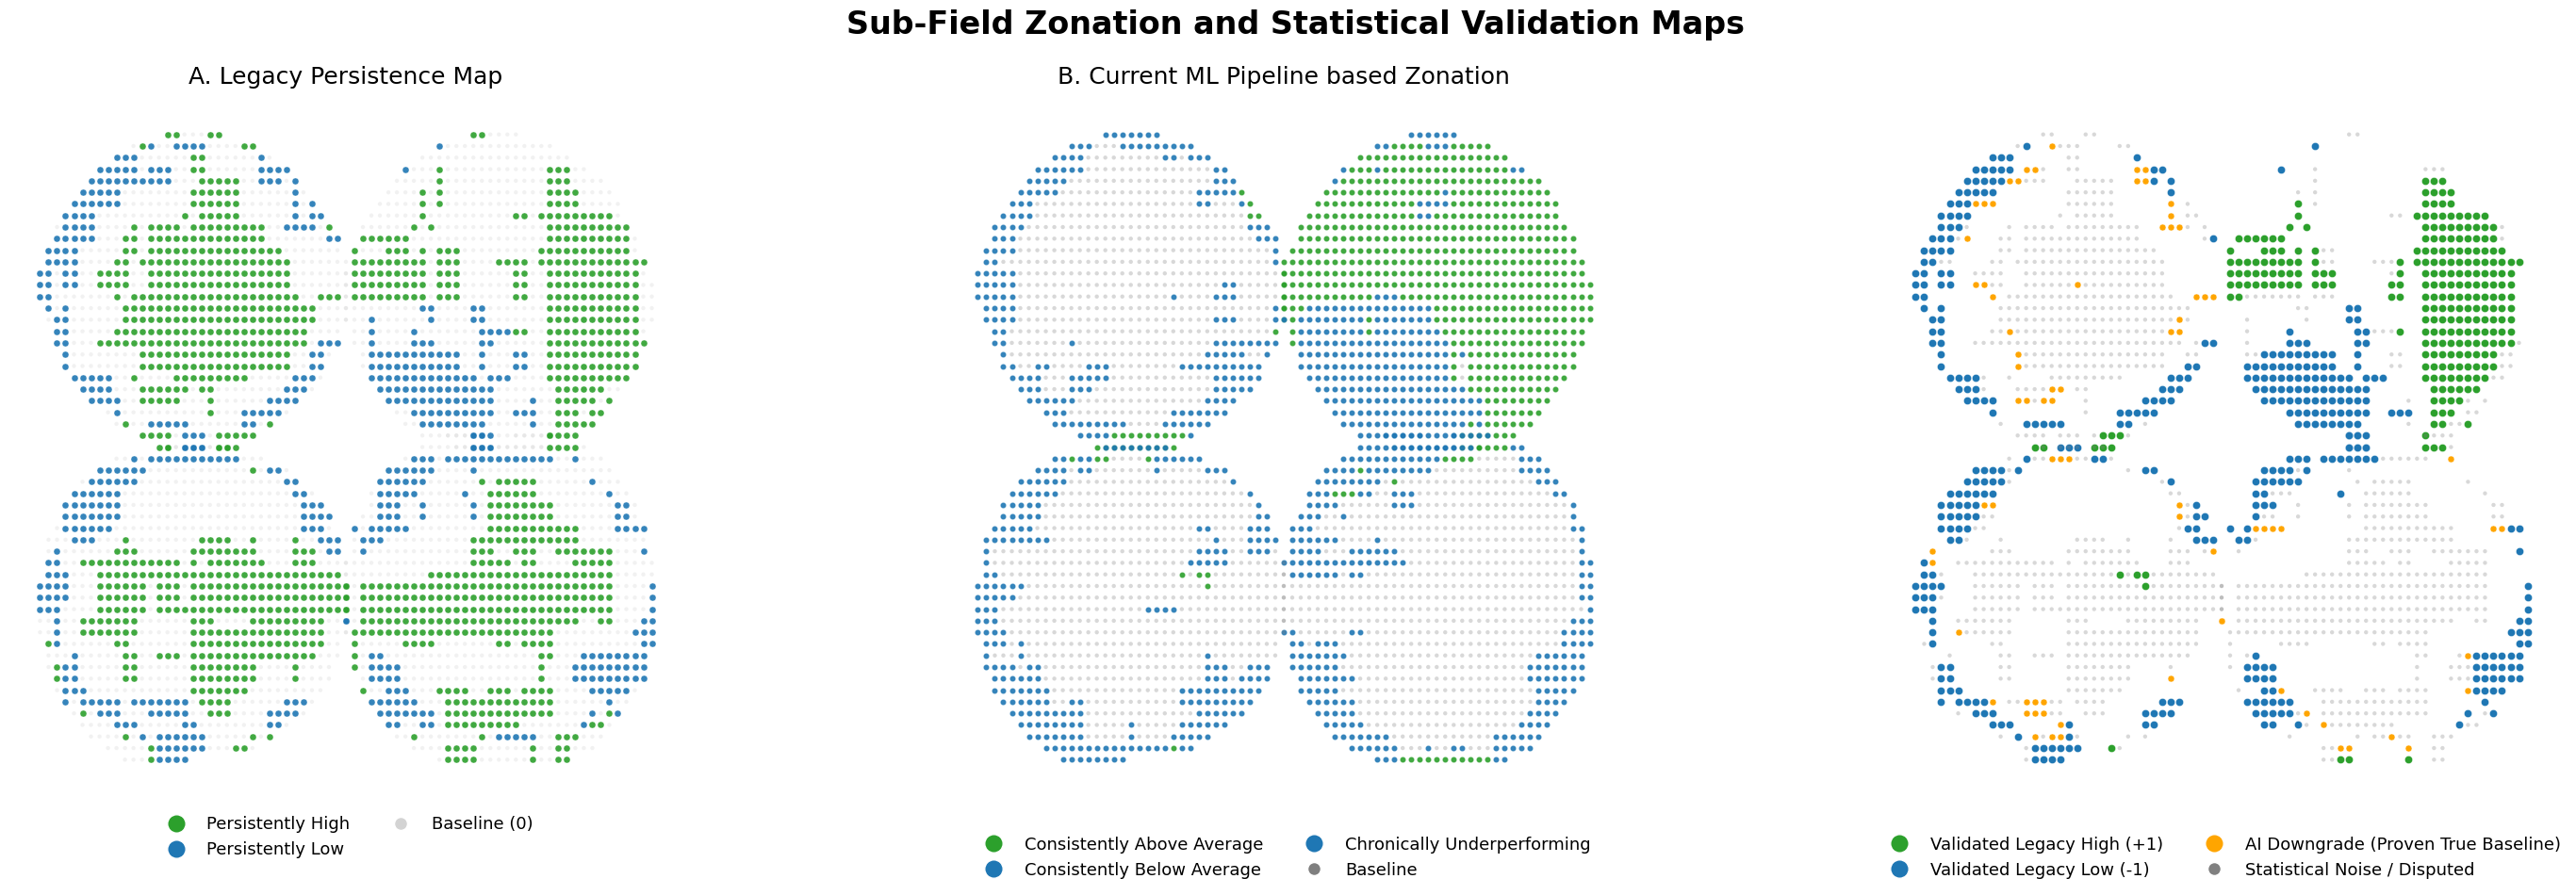

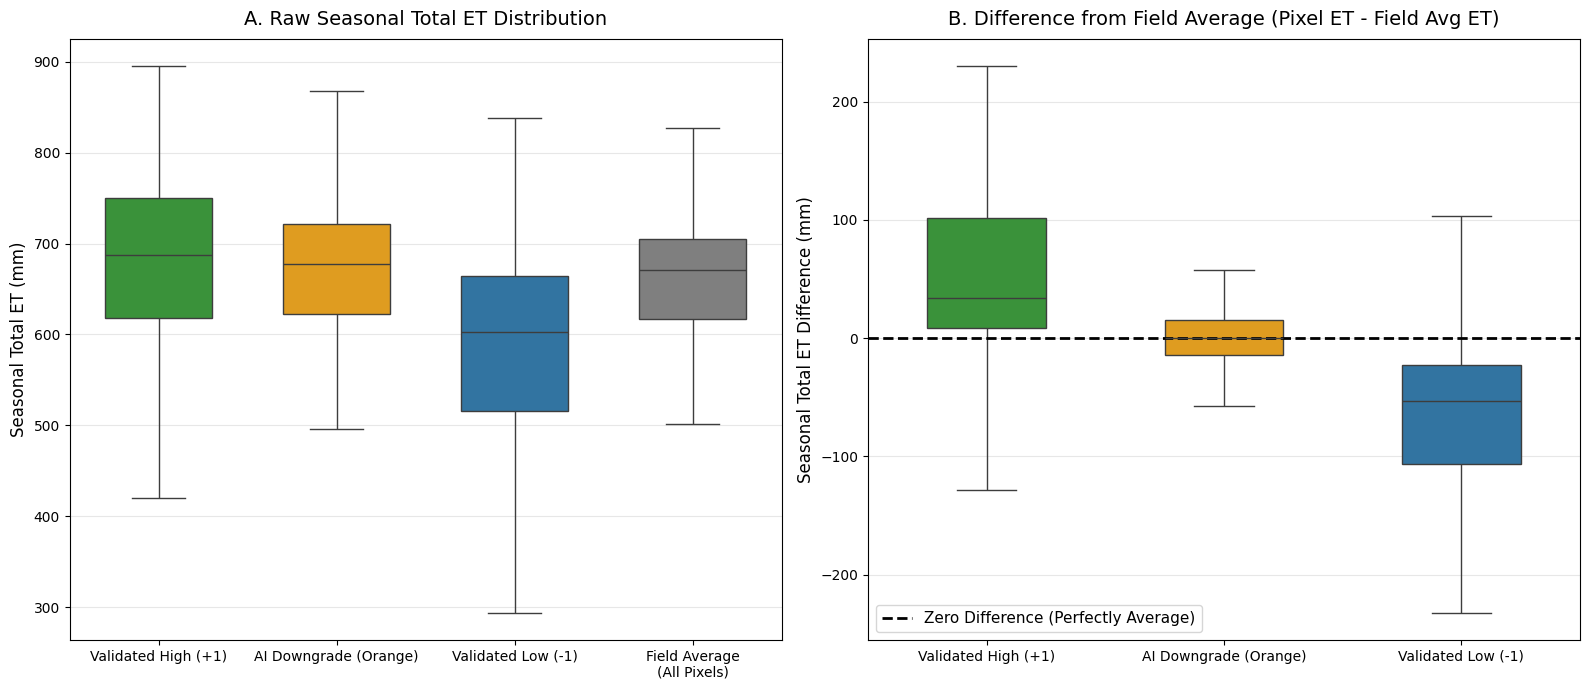

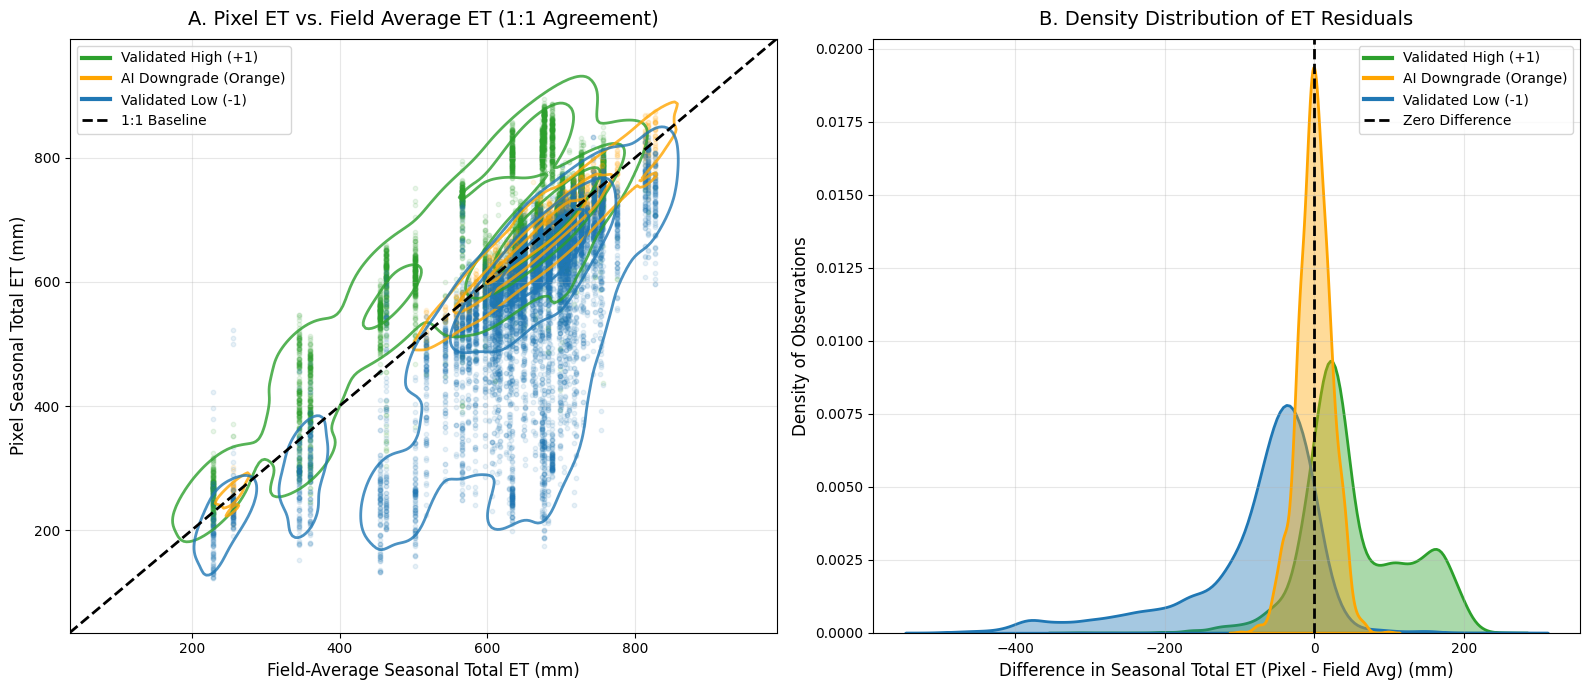

In [37]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. PREPARE THE VALIDATION DATA (From our existing master_df)
# ==============================================================================
print("1. Preparing Spatial Agreement Logic...")

# We only care about testing pixels where the Legacy map claimed a signal existed (+1 or -1)
df_val = master_df[master_df['legacy_value'].isin([-1, 1])].copy()

def define_agreement(row):
    if row['legacy_value'] == 1 and row['kmeans_mapped'] == 1:
        return 'Validated High (Match)'
    elif row['legacy_value'] == -1 and row['kmeans_mapped'] == -1:
        return 'Validated Low/Var (Match)'
    elif row['kmeans_mapped'] == 0:
        return 'AI Downgraded to Baseline'
    else:
        return 'Contradiction (Opposite)'

df_val['agreement_status'] = df_val.apply(define_agreement, axis=1)

# ==============================================================================
# 2. SEASONAL TOTALS & TRUE FIELD AVERAGE
# ==============================================================================
print("2. Aggregating to Seasonal Totals and computing True Field Averages...")
timeseries_csv = "../data/pixel_level_ET_timeseries.csv"
df_timeseries = pd.read_csv(timeseries_csv)

# Filter to target fields
df_timeseries = df_timeseries[df_timeseries['field_id'].isin([26, 27, 39, 42])]

# Create pixel ID
df_timeseries['pixel_id'] = df_timeseries['field_id'].astype(str) + "_" + \
                            df_timeseries['x'].astype(str) + "_" + \
                            df_timeseries['y'].astype(str)

# FIX 1: Convert Monthly to Seasonal Total ET
df_seasonal = df_timeseries.groupby(['pixel_id', 'field_id', 'year'])['ET'].sum().reset_index()

# FIX 2: Calculate True Field Average using ALL pixels in the field
field_yearly_avg = df_seasonal.groupby(['field_id', 'year'])['ET'].mean().reset_index(name='field_avg_ET')

# Merge true field average back into the seasonal pixel data
df_paired_full = df_seasonal.merge(field_yearly_avg, on=['field_id', 'year'])

# FIX 3: Filter down to the validation pixels for the T-Test
df_testing = df_paired_full.merge(df_val[['pixel_id', 'agreement_status']], on='pixel_id', how='inner')

# ==============================================================================
# 3. STATISTICAL T-TEST CORROBORATION
# ==============================================================================
print("3. Running Paired T-Tests on Seasonal Total ET...")

def run_paired_ttest(pixel_data):
    pixel_et = pixel_data['ET'].values
    field_avg_et = pixel_data['field_avg_ET'].values
    if len(pixel_et) < 2 or np.all(pixel_et == field_avg_et): 
        return 1.0 
    return stats.ttest_rel(pixel_et, field_avg_et)[1]

p_values_df = df_testing.groupby('pixel_id').apply(run_paired_ttest).reset_index(name='p_value')
p_values_df['is_statistically_significant'] = p_values_df['p_value'] < 0.05
df_final_stats = df_val.merge(p_values_df, on='pixel_id')

def classify_corroboration(row):
    status = row['agreement_status']
    sig = row['is_statistically_significant']
    if status == 'Validated High (Match)' and sig: return 'True Validated High (Statistically Significant)'
    if status == 'Validated Low/Var (Match)' and sig: return 'True Validated Low/Var (Statistically Significant)'
    if status == 'AI Downgraded to Baseline' and not sig: return 'Correct AI Downgrade (Statistically True Baseline)'
    return 'Statistical Noise / Disputed Boundary'

df_final_stats['corroboration_class'] = df_final_stats.apply(classify_corroboration, axis=1)

# --- Print Validation Statistics Table ---
summary_stats = df_final_stats.groupby(['agreement_status', 'is_statistically_significant']).size().unstack(fill_value=0)
summary_stats['Total Pixels'] = summary_stats.sum(axis=1)
summary_stats['% Significant (Different from Field)'] = (summary_stats[True] / summary_stats['Total Pixels']) * 100
summary_stats['% Not Significant (True Baseline)'] = (summary_stats[False] / summary_stats['Total Pixels']) * 100

print("\n--- Actual ET Paired T-Test Corroboration ---")
print(summary_stats[['Total Pixels', '% Significant (Different from Field)', '% Not Significant (True Baseline)']].round(1))

# ==============================================================================
# 4. FIGURE 1: 3-PANEL SPATIAL MAP
# ==============================================================================
print("\n4. Generating Publication Figures...")

manuscript_palette = {
    'Validated High (+1)': '#2ca02c', 
    'AI Downgrade (Orange)': 'orange', 
    'Validated Low (-1)': '#1f77b4'
}

gdf_ai = gpd.GeoDataFrame(master_df, geometry=gpd.points_from_xy(master_df.x, master_df.y), crs="EPSG:4326")
gdf_corrob = gpd.GeoDataFrame(df_final_stats, geometry=gpd.points_from_xy(df_final_stats.x, df_final_stats.y), crs="EPSG:4326")

fig1, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 10))
fig1.suptitle("Sub-Field Zonation and Statistical Validation Maps", fontsize=24, fontweight='bold', y=0.98)

# Panel A: Legacy
for val, c, l in [(1, '#2ca02c', '+1'), (-1, '#1f77b4', '-1'), (0, '#d3d3d3', '0')]:
    sub = gdf_ai[gdf_ai['legacy_value'] == val]
    if not sub.empty: 
        sub.plot(ax=ax1, color=c, markersize=25 if val!=0 else 10, alpha=0.9 if val!=0 else 0.3, edgecolor='none' if val==0 else 'white', linewidth=0.2)
ax1.set_title("A. Legacy Persistence Map", fontsize=18, pad=15)
ax1.axis('off')
legend_a = [
    Line2D([0], [0], marker='o', color='w', label='Persistently High', markerfacecolor='#2ca02c', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='Persistently Low', markerfacecolor='#1f77b4', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='Baseline (0)', markerfacecolor='#d3d3d3', markersize=10)
]
ax1.legend(handles=legend_a, loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=13, frameon=False)

# Panel B: AI
ai_colors = {"Consistently Above Average": "#2ca02c", "Consistently Below Average": "#1f77b4", "Chronically Underperforming": "#1f77b4", "Baseline": "#7f7f7f"}
for z, c in ai_colors.items():
    sub = gdf_ai[gdf_ai['historical_zone_name'] == z]
    if not sub.empty: 
        sub.plot(ax=ax2, color=c, markersize=20 if z!="Baseline" else 10, alpha=0.9 if z!="Baseline" else 0.3, edgecolor='none' if z=="Baseline" else 'white', linewidth=0.2)
ax2.set_title("B. Current ML Pipeline based Zonation", fontsize=18, pad=15)
ax2.axis('off')
legend_b = [Line2D([0], [0], marker='o', color='w', label=z, markerfacecolor=c, markersize=14 if z!="Baseline" else 10) for z, c in ai_colors.items()]
ax2.legend(handles=legend_b, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=13, frameon=False)


# Panel C: Validation
corrob_settings = [
    ('True Validated High (Statistically Significant)', '#2ca02c', 35, 'Validated Legacy High (+1)'), 
    ('True Validated Low/Var (Statistically Significant)', '#1f77b4', 35, 'Validated Legacy Low (-1)'), 
    ('Correct AI Downgrade (Statistically True Baseline)', 'orange', 25, 'AI Downgrade (Proven True Baseline)'), 
    ('Statistical Noise / Disputed Boundary', 'grey', 10, 'Statistical Noise / Disputed')
]
legend_c = []
for cls, c, s, label in corrob_settings:
    sub = gdf_corrob[gdf_corrob['corroboration_class'] == cls]
    if not sub.empty: 
        sub.plot(ax=ax3, color=c, markersize=s, alpha=1.0 if s>10 else 0.3, edgecolor='white' if s>10 else 'none', linewidth=0.3)
    legend_c.append(Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=c, markersize=14 if s>10 else 10))
# ax3.set_title("C. Statistical Validation via Actual ET", fontsize=18, pad=15)
ax3.axis('off')
ax3.legend(handles=legend_c, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=13, frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.88)
plt.savefig("./Figure3.png", dpi =300)
plt.show()

# ==============================================================================
# 5. FIGURE 2: BOXPLOTS
# ==============================================================================
df_box = df_testing.merge(df_final_stats[['pixel_id', 'corroboration_class']], on='pixel_id', how='inner')
df_box['ET_Difference_mm'] = df_box['ET'] - df_box['field_avg_ET']

target_classes = {
    'True Validated High (Statistically Significant)': 'Validated High (+1)',
    'Correct AI Downgrade (Statistically True Baseline)': 'AI Downgrade (Orange)',
    'True Validated Low/Var (Statistically Significant)': 'Validated Low (-1)'
}
df_box = df_box[df_box['corroboration_class'].isin(target_classes.keys())].copy()
df_box['Class'] = df_box['corroboration_class'].map(target_classes)

raw_et_data = df_box[['Class', 'ET']].rename(columns={'ET': 'Value'})
field_baseline = df_box[['field_id', 'year', 'field_avg_ET']].drop_duplicates()
field_baseline['Class'] = 'Field Average\n(All Pixels)'
field_baseline = field_baseline.rename(columns={'field_avg_ET': 'Value'})[['Class', 'Value']]
df_raw_plot = pd.concat([raw_et_data, field_baseline], ignore_index=True)

fig2, (axA, axB) = plt.subplots(1, 2, figsize=(16, 7))
# fig2.suptitle("Seasonal Total ET Boxplots: Physical Verification of the AI Downgrade", fontsize=18, fontweight='bold', y=1.02)

raw_order = ['Validated High (+1)', 'AI Downgrade (Orange)', 'Validated Low (-1)', 'Field Average\n(All Pixels)']
raw_palette = {**manuscript_palette, 'Field Average\n(All Pixels)': '#7f7f7f'}
sns.boxplot(data=df_raw_plot, x='Class', y='Value', order=raw_order, palette=raw_palette, ax=axA, showfliers=False, width=0.6)
axA.set_title("A. Raw Seasonal Total ET Distribution", fontsize=14, pad=10)
axA.set_ylabel("Seasonal Total ET (mm)", fontsize=12)
axA.set_xlabel(""); axA.grid(alpha=0.3, axis='y')

order = ['Validated High (+1)', 'AI Downgrade (Orange)', 'Validated Low (-1)']
sns.boxplot(data=df_box, x='Class', y='ET_Difference_mm', order=order, palette=manuscript_palette, ax=axB, showfliers=False, width=0.5)
axB.axhline(0, color='black', linestyle='--', linewidth=2, label='Zero Difference (Perfectly Average)')
axB.set_title("B. Difference from Field Average (Pixel ET - Field Avg ET)", fontsize=14, pad=10)
axB.set_ylabel("Seasonal Total ET Difference (mm)", fontsize=12)
axB.set_xlabel("")
axB.legend(loc='lower left', fontsize=11)
axB.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("./Figure5.png", dpi =300)
plt.show()

# ==============================================================================
# 6. FIGURE 3: SCATTER & DENSITY
# ==============================================================================
fig3, (axC, axD) = plt.subplots(1, 2, figsize=(16, 7))
# fig3.suptitle("Physical Verification using Seasonal Total Evapotranspiration (ET)", fontsize=18, fontweight='bold', y=1.02)

for cls_name, color in manuscript_palette.items():
    subset = df_box[df_box['Class'] == cls_name]
    axC.scatter(subset['field_avg_ET'], subset['ET'], color=color, alpha=0.1, s=10, label='_nolegend_')
    sns.kdeplot(x=subset['field_avg_ET'], y=subset['ET'], ax=axC, color=color, levels=4, linewidths=2, alpha=0.8)

lims = [np.min([axC.get_xlim(), axC.get_ylim()]), np.max([axC.get_xlim(), axC.get_ylim()])]
axC.plot(lims, lims, 'k--', linewidth=2, label='1:1 Line (Perfect Baseline)', zorder=10)
axC.set_xlim(lims); axC.set_ylim(lims)
axC.set_title("A. Pixel ET vs. Field Average ET (1:1 Agreement)", fontsize=14, pad=10)
axC.set_xlabel("Field-Average Seasonal Total ET (mm)", fontsize=12)
axC.set_ylabel("Pixel Seasonal Total ET (mm)", fontsize=12); axC.grid(alpha=0.3)
axC.legend(handles=[Line2D([0], [0], color=c, lw=3, label=l) for l, c in manuscript_palette.items()] + [Line2D([0], [0], color='black', lw=2, linestyle='--', label='1:1 Baseline')], loc='upper left')

sns.kdeplot(data=df_box, x='ET_Difference_mm', hue='Class', palette=manuscript_palette, fill=True, common_norm=False, alpha=0.4, linewidth=2, ax=axD, legend=False)
axD.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero Difference')
axD.set_title("B. Density Distribution of ET Residuals", fontsize=14, pad=10)
axD.set_xlabel("Difference in Seasonal Total ET (Pixel - Field Avg) (mm)", fontsize=12)
axD.set_ylabel("Density of Observations", fontsize=12); axD.grid(alpha=0.3)
axD.legend(handles=[Line2D([0], [0], color=c, lw=3, label=l) for l, c in manuscript_palette.items()] + [Line2D([0], [0], color='black', lw=2, linestyle='--', label='Zero Difference')], loc='upper right')

plt.tight_layout()
plt.savefig("./Figure6.png", dpi =300)
plt.show()



Running Paired T-Tests...

--- Paired T-Test Corroboration ---
is_significant             Total Pixels  % Significant (Different from Field)  \
agreement_status                                                                
AI Downgraded to Baseline           966                                   4.7   
Contradiction (Opposite)            121                                  32.2   
Validated High (Match)              304                                  47.7   
Validated Low/Var (Match)           444                                  60.4   

is_significant             % Not Significant (Baseline-like)  
agreement_status                                              
AI Downgraded to Baseline                               95.3  
Contradiction (Opposite)                                67.8  
Validated High (Match)                                  52.3  
Validated Low/Var (Match)                               39.6  


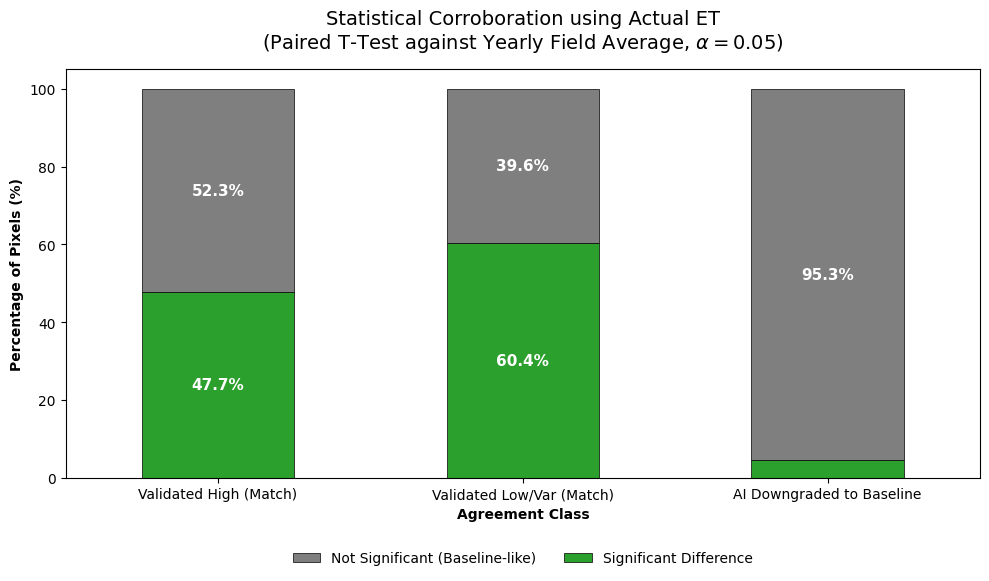

In [38]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. LOAD DATA
# ==============================================================================
input_csv = "../data/pixel_level_ET_timeseries.csv"
df_timeseries = pd.read_csv(input_csv)

# Create pixel ID
df_timeseries['pixel_id'] = (
    df_timeseries['field_id'].astype(str) + "_" +
    df_timeseries['x'].astype(str) + "_" +
    df_timeseries['y'].astype(str)
)

# df_val must already exist:
# columns: pixel_id, agreement_status

# ==============================================================================
# 2. TRUE FIELD AVERAGE (FIXED - USE ALL PIXELS)
# ==============================================================================
et_column = 'ET'

field_yearly_avg = (
    df_timeseries
    .groupby(['field_id', 'year'])[et_column]
    .mean()
    .reset_index(name='field_avg_ET')
)

# Merge baseline into full dataset
df_paired_full = df_timeseries.merge(field_yearly_avg, on=['field_id', 'year'])

# Now filter to validation pixels
df_testing = df_paired_full.merge(
    df_val[['pixel_id', 'agreement_status']],
    on='pixel_id',
    how='inner'
)

# ==============================================================================
# 3. PAIRED T-TEST
# ==============================================================================
print("Running Paired T-Tests...")

def run_paired_ttest(pixel_data):
    x = pixel_data[et_column].values
    y = pixel_data['field_avg_ET'].values

    # Safety check
    if len(x) < 2:
        return 1.0

    # If no variation
    if np.std(x - y) == 0:
        return 1.0

    _, p_val = stats.ttest_rel(x, y)
    return p_val

p_values_df = (
    df_testing
    .groupby('pixel_id')
    .apply(run_paired_ttest)
    .reset_index(name='p_value')
)

# Significance flag
p_values_df['is_significant'] = p_values_df['p_value'] < 0.05

# Merge results
df_final = df_val.merge(p_values_df, on='pixel_id')

# ==============================================================================
# 4. SUMMARY STATISTICS 
# ==============================================================================
summary = (
    df_final
    .groupby(['agreement_status', 'is_significant'])
    .size()
    .unstack(fill_value=0)
)

# Ensure both columns exist
if True not in summary.columns:
    summary[True] = 0
if False not in summary.columns:
    summary[False] = 0

summary['Total Pixels'] = summary[True] + summary[False]

summary['% Significant (Different from Field)'] = (
    summary[True] / summary['Total Pixels'] * 100
)

summary['% Not Significant (Baseline-like)'] = (
    summary[False] / summary['Total Pixels'] * 100
)

print("\n--- Paired T-Test Corroboration ---")
print(summary[['Total Pixels',
               '% Significant (Different from Field)',
               '% Not Significant (Baseline-like)']].round(1))

# ==============================================================================
# 5. PLOT
# ==============================================================================
plot_data = summary[
    ['% Significant (Different from Field)',
     '% Not Significant (Baseline-like)']
].copy()

order = [
    'Validated High (Match)',
    'Validated Low/Var (Match)',
    'AI Downgraded to Baseline'
]

plot_data = plot_data.reindex(order)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ca02c', '#7f7f7f']  # green = significant, grey = baseline-like

plot_data.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

# Labels
for c in ax.containers:
    labels = [
        f"{v.get_height():.1f}%" if v.get_height() > 5 else ""
        for v in c
    ]
    ax.bar_label(c, labels=labels, label_type='center',
                 color='white', fontsize=11, fontweight='bold')

plt.title("Statistical Corroboration using Actual ET\n(Paired T-Test against Yearly Field Average, $\\alpha=0.05$)", fontsize=14, pad=15)

plt.ylabel("Percentage of Pixels (%)", fontweight='bold')
plt.xlabel("Agreement Class", fontweight='bold')
plt.xticks(rotation=0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    ['Not Significant (Baseline-like)', 'Significant Difference'],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.savefig("./Figure4.png", dpi =300)
plt.show()

1. Loading Data...
2. Pivoting Time Series...
3. Selecting Representative Pixels...
4. Loading Chronos Model...
5. Generating plots...


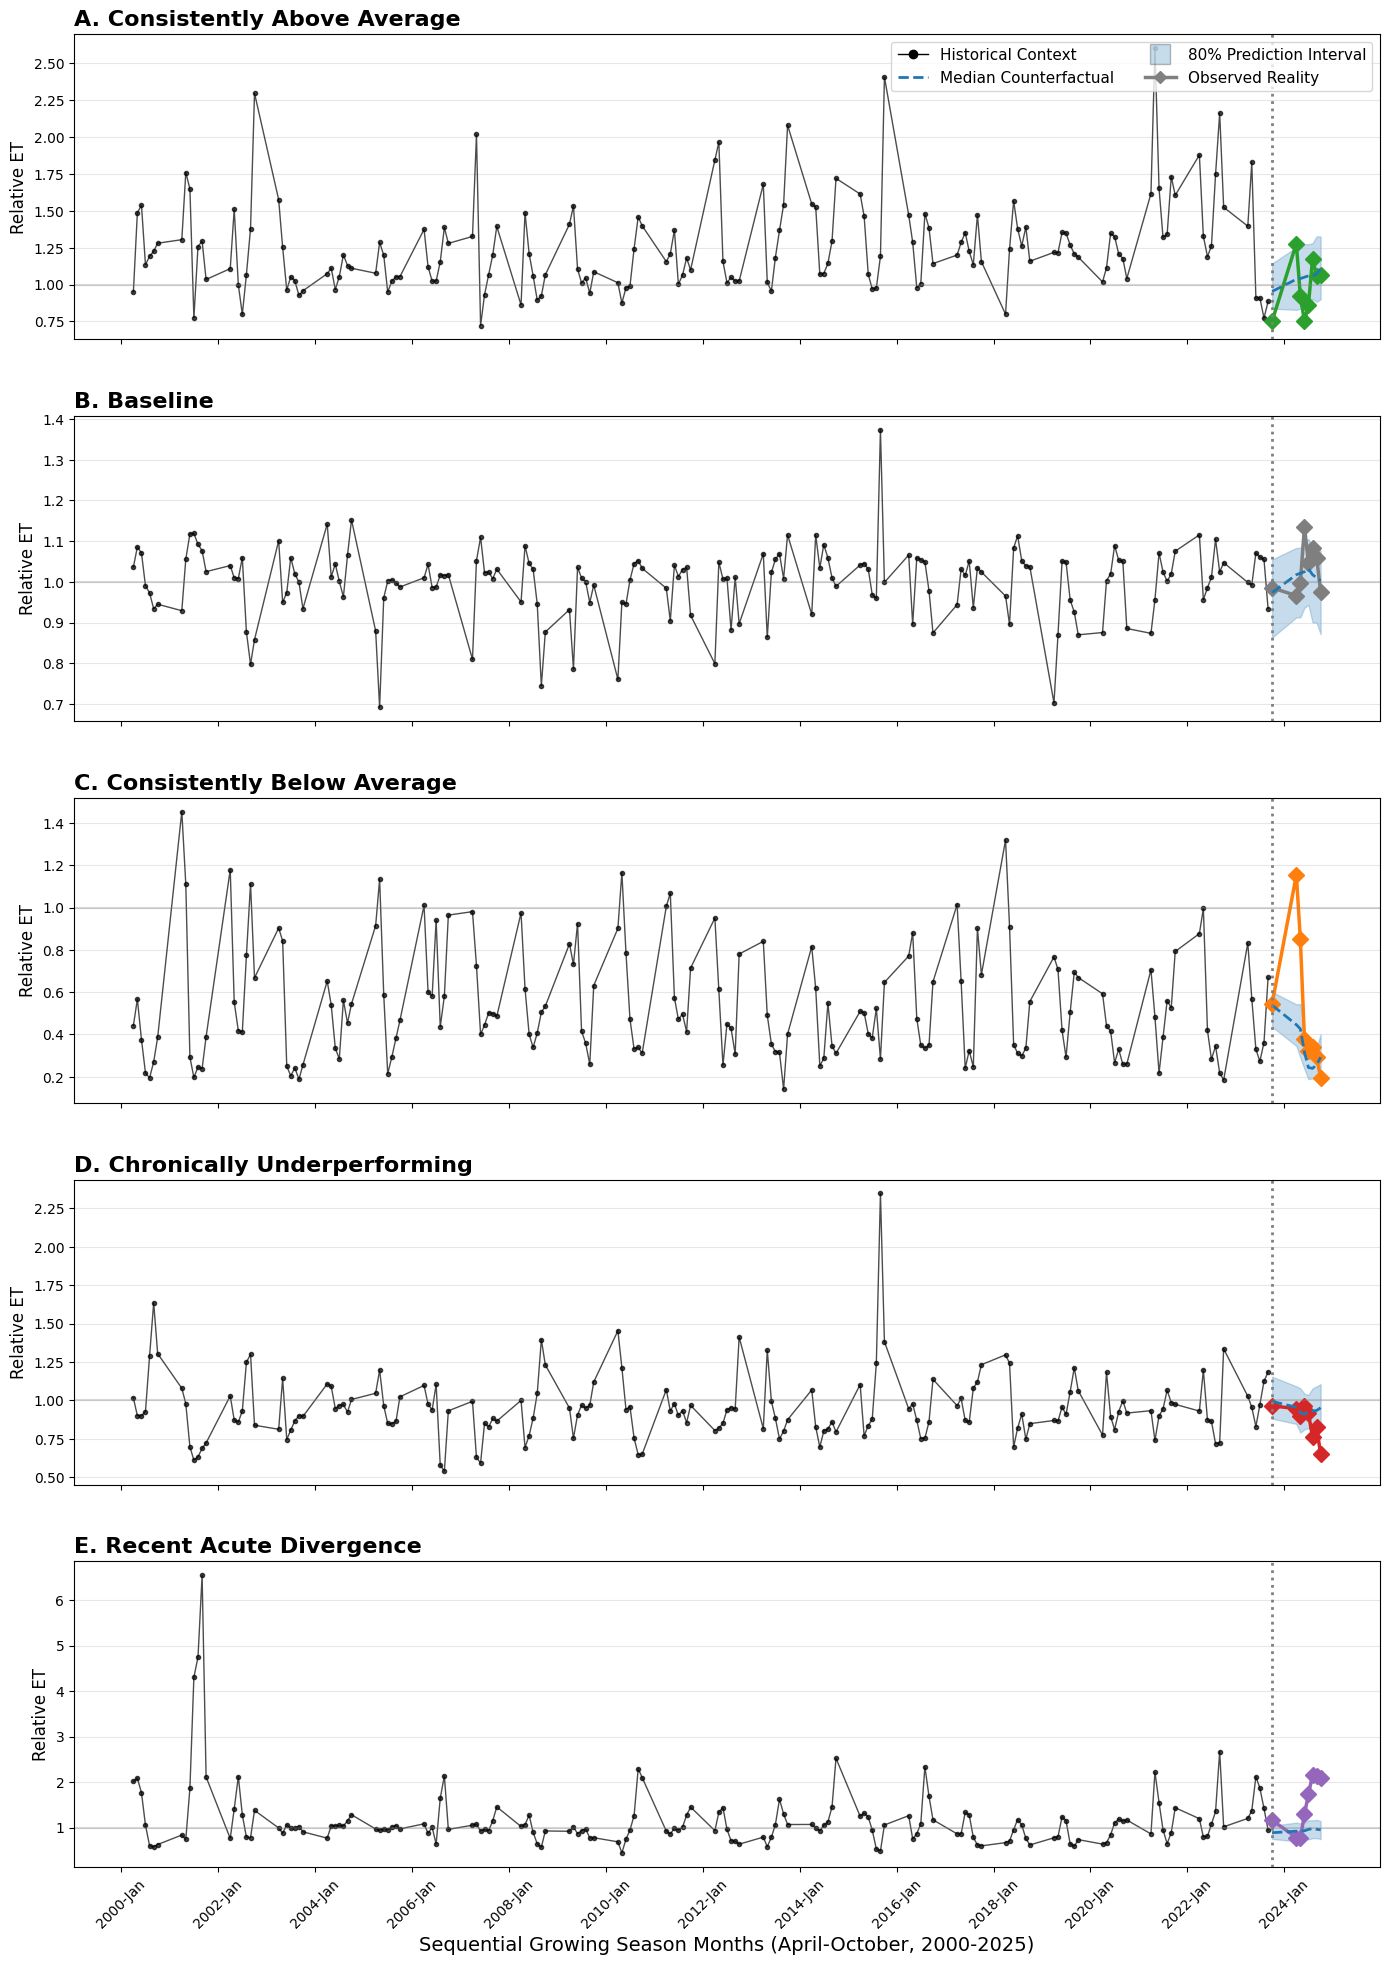

In [41]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from chronos import ChronosPipeline
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD AND PIVOT TIME SERIES
# ==========================================
print("1. Loading Data...")
input_csv = "../data/pixel_level_ET_timeseries.csv"
df = pd.read_csv(input_csv)

df = df[df['field_id'].isin([26, 27, 39, 42])]

df['pixel_id'] = df['field_id'].astype(str) + "_" + df['x'].astype(str) + "_" + df['y'].astype(str)

print("2. Pivoting Time Series...")
pivot_df = df.pivot(index='pixel_id', columns=['year', 'month'], values='relative_ET')

# ---- FIX: build real datetime axis ----
dates = pd.to_datetime([f"{y}-{m:02d}-01" for y, m in pivot_df.columns])

# print(pivot_df.head())

# ==========================================
# 2. SELECT REPRESENTATIVE PIXELS
# ==========================================
print("3. Selecting Representative Pixels...")
target_pixels = {}

subset_acute = master_df[master_df['current_zone_name'] == "Recent Acute Divergence"]
target_pixels['Recent Acute Divergence'] = subset_acute.nlargest(1, 'chronos_anomaly_score')['pixel_id'].values[0]

subset_above = master_df[master_df['current_zone_name'] == "Consistently Above Average"]
target_pixels['Consistently Above Average'] = subset_above.nlargest(1, 'lt_mean')['pixel_id'].values[0]

subset_below = master_df[master_df['current_zone_name'] == "Consistently Below Average"]
target_pixels['Consistently Below Average'] = subset_below.nsmallest(1, 'lt_mean')['pixel_id'].values[0]

subset_under = master_df[master_df['current_zone_name'] == "Chronically Underperforming"]
target_pixels['Chronically Underperforming'] = subset_under.nlargest(1, 'lt_std')['pixel_id'].values[0]

subset_base = master_df[master_df['current_zone_name'] == "Baseline"].copy()
subset_base['dist_to_1'] = abs(subset_base['lt_mean'] - 1.0)
target_pixels['Baseline'] = subset_base.nsmallest(1, 'dist_to_1')['pixel_id'].values[0]

# ==========================================
# 3. CHRONOS MODEL
# ==========================================
print("4. Loading Chronos Model...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.float32,
)

# ==========================================
# 4. PLOTTING
# ==========================================
scientific_colors = {
    "Consistently Above Average": "#2ca02c",
    "Baseline": "#7f7f7f",
    "Consistently Below Average": "#ff7f0e",
    "Chronically Underperforming": "#d62728",
    "Recent Acute Divergence": "#9467bd"
}

zone_order = [
    "Consistently Above Average",
    "Baseline",
    "Consistently Below Average",
    "Chronically Underperforming",
    "Recent Acute Divergence"
]

fig, axes = plt.subplots(5, 1, figsize=(14, 22), sharex=True)

context_cutoff = -8

print("5. Generating plots...")
for i, zone_name in enumerate(zone_order):

    pid = target_pixels[zone_name]
    ax = axes[i]

    pixel_history = pivot_df.loc[pid].values
    context_tensor = torch.tensor(pixel_history[:context_cutoff], dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        forecast = pipeline.predict(context_tensor, prediction_length=8, num_samples=100)
        forecast_samples = forecast[0].numpy()

    median = np.median(forecast_samples, axis=0)
    low_bound = np.percentile(forecast_samples, 10, axis=0)
    high_bound = np.percentile(forecast_samples, 90, axis=0)

    zone_color = scientific_colors[zone_name]

    # ---- FIX: date axis instead of integers ----
    hist_dates = dates[:context_cutoff]
    test_dates = dates[context_cutoff:]

    ax.plot(hist_dates, pixel_history[:context_cutoff],
            color='black', marker='o', markersize=3, linewidth=1, alpha=0.7)

    ax.plot(test_dates, pixel_history[context_cutoff:],
            color=zone_color, marker='D', markersize=8, linewidth=2.5)

    ax.plot(test_dates, median, color='#1f77b4', linestyle='--', linewidth=2)

    ax.fill_between(test_dates, low_bound, high_bound, color='#1f77b4', alpha=0.25)

    ax.axvline(test_dates[0], color='gray', linestyle=':', linewidth=2)
    ax.axhline(1.0, color='gray', linestyle='-', alpha=0.3)

    ax.set_title(f"{chr(65+i)}. {zone_name}", fontsize=16, fontweight='bold', loc='left')
    ax.set_ylabel("Relative ET", fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    # 
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    ax.tick_params(axis='x', rotation=45)

    if i == 0:
        custom_lines = [
            Line2D([0], [0], color='black', marker='o', lw=1, label='Historical Context'),
            Line2D([0], [0], color='#1f77b4', linestyle='--', lw=2, label='Median Counterfactual'),
            Line2D([0], [0], color='none', marker='s', markersize=15,
                   markerfacecolor='#1f77b4', alpha=0.25, label='80% Prediction Interval'),
            Line2D([0], [0], color='gray', marker='D', lw=2.5, label='Observed Reality')
        ]

        ax.legend(handles=custom_lines, loc='upper right', frameon=True, fontsize=11, ncol=2)

axes[-1].set_xlabel("Sequential Growing Season Months (April-October, 2000-2025)", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.25)
plt.savefig("./Figure7.png", dpi=300)
plt.show()